In [1]:
import numpy as np
import matplotlib.pyplot as plt
#!pip install scipy
from scipy import stats
from scipy import optimize

### Assumptions of this model:
- ### All the quantities are **fixed** and don't vary with time.
- ### Ad's quality $q_a$ and profit-per-click $v_a$ don't depend on the slot.
- ### Prominence $\lambda_s$ doesn't depend on the ad.

In [2]:
class Auction:
    def __init__(self, *args, **kwargs):
        pass

    def get_winners(self, bids):
        pass

    def get_payments_per_click(self, winners, bids):
        pass

    def round(self, bids):
        winners = self.get_winners(bids) # allocation mechanism!
        payments_per_click = self.get_payments_per_click(winners, bids)
        return winners, payments_per_click

In [3]:
class FirstPriceAuction(Auction):
    def __init__(self, qs):
        self.qs = qs
        self.n_adv = len(self.qs)
    
    def get_winners(self, bids):
        public_values = self.qs*bids
        public_ranking = np.argsort(public_values)
        winner = public_ranking[-1] # <--------------------- The only difference with second price auction implementation
        return winner
    
    def get_payments_per_click(self, winners, bids):
        payment = bids[winners]
        return payment

Let's formalize the dynamics as follows, for each round $t \in [T]$:

1. You choose a bid $b_t \in [0,1]$ at time $t$.
2. The competition's highest bid $m_t$ is realized.
3. If $b_t \geq m_t$, you win and get utility

$$
f_t(b_t) = v - b_t,
$$

and pay a cost equal to the proposed bid $b_t$. Otherwise, both are $0$. We assumed from now on that $q_s*\lambda_s=1$ (CTR=1)

In [16]:
# advertisers' fixed parameters
n_adv = 4 # four advertisers
qs = np.array([1, 1, 1, 1]) # quality scores
v = np.array([0.7, 1.1, 1.4, 0.85]) # valuations
possible_bids_space = np.linspace(0.05, 1, 20) # possible bids space

print(f'Possible bids space: {possible_bids_space}')

assert len(qs) == n_adv
assert len(v) == n_adv

# environmental settings
n_users= 3

auction = FirstPriceAuction(qs=qs)
for u in range(n_users):
    print(f'# User {u}')
    bids = np.random.choice(possible_bids_space, size=n_adv)
    pub_values = bids*qs
    print(f'Bids: {bids}, Publisher Values: {pub_values}')
    winner, payment_per_click = auction.round(bids=bids)
    utility = np.zeros(n_adv)
    utility[winner] = v[winner] - payment_per_click
    print(f'Auction Winner: {winner}, Payment-per-click: {payment_per_click}')
    print(f'Utilities: {utility}')
    print(f'Payment == Bid : {payment_per_click == bids[winner]}')

Possible bids space: [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95 1.  ]
# User 0
Bids: [0.8  0.1  0.25 0.35], Publisher Values: [0.8  0.1  0.25 0.35]
Auction Winner: 0, Payment-per-click: 0.7999999999999999
Utilities: [-0.1  0.   0.   0. ]
Payment == Bid : True
# User 1
Bids: [0.6  0.95 0.95 0.1 ], Publisher Values: [0.6  0.95 0.95 0.1 ]
Auction Winner: 2, Payment-per-click: 0.95
Utilities: [0.   0.   0.45 0.  ]
Payment == Bid : True
# User 2
Bids: [0.1  0.95 0.75 0.25], Publisher Values: [0.1  0.95 0.75 0.25]
Auction Winner: 1, Payment-per-click: 0.95
Utilities: [0.   0.15 0.   0.  ]
Payment == Bid : True


The idea in the previous code is just showcasing that there 4 bids, therefore i=4, and maken them to play the first price auction and win the ones always who bidf the highest. In this case we are not imposing the case where $b_t>v_i$ for each $i$, so we could get negatives. This is just exploratory.

## Advertiser's Perspective: learning in repeated first price auctions

### We assume from now on that all CTRs are equal to 1
## Stochatic setting

C:\Users\Recup\AppData\Local\Temp\ipykernel_31404\2044859251.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


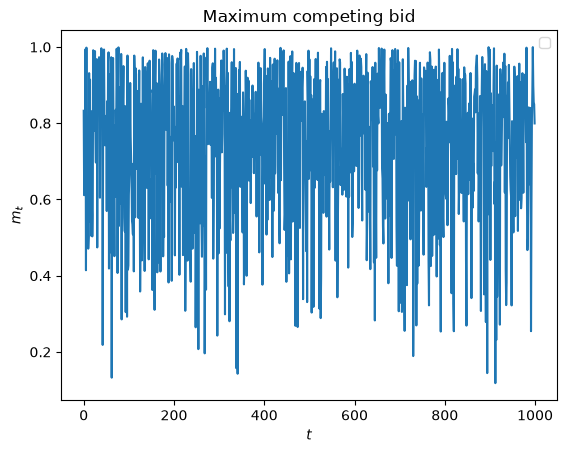

In [ ]:
### Stochastic Bidders: my competitors sample their bids from 
### probability distributions

n_advertisers = 3
n_users = 1000 #T-rounds
B = 150
my_valuation = 0.6
rho = B/n_users

# simple scenario: competitors sample bids from a uniform 
other_bids = np.random.uniform(0, 1, size = (n_advertisers, n_users))
# I assume that competitors may have a larger budget than mine, but they may
# not deplete it.
m_t = other_bids.max(axis=0)

plt.title("Maximum competing bid")
plt.plot(m_t)
plt.xlabel('$t$')
plt.ylabel('$m_t$')
plt.legend()
plt.show()

This code generates the realized maximum competing bid for each round.

### When the competing bids are $b_i \sim U([0,1]), i=1,\dots,k$,  the maximum is $m_t \sim Beta(k,1)$. **We will assume this model now.**

Possible bids space: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


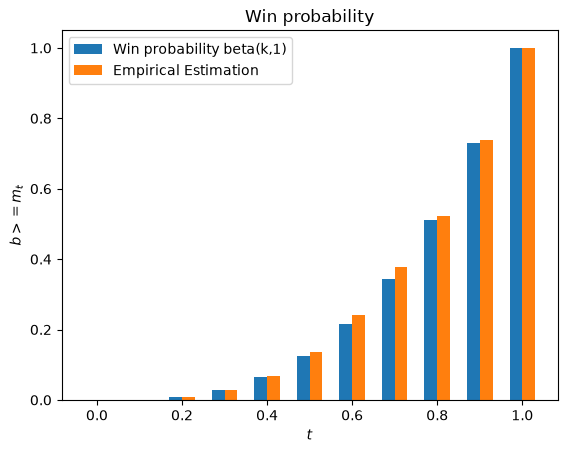

In [22]:
### the maximum among k uniformly distributed r.v.s is a beta r.v. with alpha=k and beta=1
available_bids = np.linspace(0,1,11)
print(f'Possible bids space: {available_bids}')

# This functions recieve a array of possible bids and return the beta(n_advertisers, 1) CDF evaluated 
# at those bids. This is the theoretical win probability of a bid b >= m_t

win_probabilities = stats.beta.cdf(available_bids, n_advertisers, 1)

emp_win_probabilities = np.array([np.sum(b >= m_t) for b in available_bids])/len(m_t)

plt.title("Win probability")
width = 0.03
plt.bar(available_bids -width/2, win_probabilities, width=width, align='center', label='Win probability beta(k,1)')
plt.bar(available_bids +width/2, emp_win_probabilities, width=width, align='center', label='Empirical Estimation')
plt.xlabel('$t$')
plt.ylabel('$b >= m_t$')
plt.legend()
plt.show()

# Witouth Budget

## What's the baseline (the clairvoyant)?

So we know that the utility (reward9) is 

$$
f(b) = (v-b)\,\mathbb{P}(b \geq m_t)
$$

So the expected reward is 

$$
E[f(b)] = (v-b)\,E[\mathbb{P}(b \geq m_t)]
$$

In [ ]:
# ----- Clairvoyant WITHOUT budget constraint -----
# With no budget, the best the clairvoyant can do is commit to a single
# fixed bid (no need to randomize) that maximizes expected per-round utility.

expected_utilities = (my_valuation - available_bids) * win_probabilities
best_bid_idx = np.argmax(expected_utilities)
best_bid = available_bids[best_bid_idx]
clairvoyant_utility_no_budget = expected_utilities[best_bid_idx]

print(f'Best fixed bid (no budget): {best_bid:.3f}')
print(f'Expected per-round utility: {clairvoyant_utility_no_budget:.4f}')
print(f'Expected utility over T={n_users} rounds: {n_users*clairvoyant_utility_no_budget:.2f}')

# With Budget

## What's the baseline (the clairvoyant)?

We are in a **stochastic** environment, so we use the clairvoyant **in expectation**: it knows the *distribution* of $m_t$ (not the realizations) and only has to satisfy the budget **in expectation**, i.e.

$$
\text{maximize}_{\gamma \in \Delta(\mathcal B)} \;\; \sum_b \gamma(b)\,(v-b)\,\mathbb{P}(b \ge m) \quad \text{s.t.} \quad \sum_b \gamma(b)\, b\, \mathbb{P}(b \ge m) \le \rho, \qquad \rho = \frac{B}{T}
$$

$$
\sum_b \gamma(b) = 1, \qquad 0 \le \gamma(b) \le 1 \;\; \forall b
$$

This is a **Linear Program**: $\gamma$ is a distribution over the (small, discrete) bid set — to hit the budget exactly, the clairvoyant may need to *randomize* between (at most) two bids, unlike the no-budget case. Its optimal value $T\cdot f(\gamma^\star)$ is the benchmark $OPT$ against which we measure the regret of the budget-constrained UCB-like agent.

In [ ]:
## Linear Program: clairvoyant WITH budget constraint
def compute_clairvoyant(available_bids, valuation, rho, win_probabilities):
    c = -(valuation - available_bids) * win_probabilities  # linprog minimizes -> negate
    A_ub = [available_bids * win_probabilities]
    b_ub = [rho]
    A_eq = [np.ones(len(available_bids))]
    b_eq = [1]
    res = optimize.linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=(0, 1))
    gamma = res.x
    expected_utility = -res.fun
    expected_payment = np.sum(available_bids * gamma * win_probabilities)
    return gamma, expected_utility, expected_payment

rho = B / n_users
gamma_clairvoyant, clairvoyant_utility, clairvoyant_payment = compute_clairvoyant(
    available_bids, my_valuation, rho, win_probabilities
)

print(f'rho = {rho:.4f}')
print(f'gamma (bid distribution) = {gamma_clairvoyant}')
print(f'Expected per-round utility = {clairvoyant_utility:.4f}')
print(f'Expected per-round payment = {clairvoyant_payment:.4f} (must be <= rho)')
print(f'Expected utility over T={n_users} rounds: {n_users*clairvoyant_utility:.2f}')